# 2.4 CRE–Gene Association via Regression

## How much variance in gene expression can a regression model explain per gene

### Theory and Implementation

<h3> Ridge Regression and Cross Validation </h3>

In the linear regression model, parameters are estimated using the least-squares method to minimize the sum of squared residuals. However, strong correlation between features leads to overly large coefficients. Thus, the linear regression model was too unreliable due to excessive collinearity among the peaks.

**Ridge Regression** is applied, which introduces a penalty for excessively large coefficients to increase model stability.

$$\min_{w} \vert{}\vert{}Xw - y\vert{}\vert{}^2_2 + \alpha \vert{}\vert{}w\vert{}\vert{}^2_2$$

* **Least squares part:** $$\vert{}\vert{}Xw - y\vert{}\vert{}^2_2$$ 
* **Penalty part ($\alpha$):** $$\alpha \vert{}\vert{}w\vert{}\vert{}^2_2$$

**Cross-validation** was used for control:
1. The dataset is split into $K$ blocks of equal size.
2. The model is then trained and tested 5 times.
3. In each round, a different block is used as test data, while the remaining four blocks serve as training data.

<h3> Python Implementation</h3>

* One model is trained across all cell types.
* One model is trained specific to γδ T-cells.

<h5> Workflow</h5>

1. **Select genes**
   * γδ T-cells specific genes (from section 2.2: Genes with a high Gini coefficient from the γδ T-cell specific lineage).
2. **Filter ATAC data:** Extract peaks within 100Kb of the selected gene's region.
3. **Build Matrix and Ridge Regression.**

### Function of the regression model (R^2): all cell types

<h3> Preparing Dataset

In [1]:
import pandas as pd
from pathlib import Path

RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)

ATAC_pfiltered_path = Path('data') / 'ATAC_pfiltered.csv'
ATAC_seq = pd.read_csv(ATAC_pfiltered_path)
ATAC_seq

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


**Function R^2_gen**

1. Create a matrix: X = peaks, Y = gene expression
2. Run Ridge Regression to select best alpha
3. Cross Validation with best alpha
4. Plot predicted values vs actual values 
5. Create residual plot

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen(gen_name, plot=True, plot_residues=True): 
    
    #Y: Gen-Expression
    RNA_seq_gen = RNA_seq[RNA_seq["Unnamed: 0"] == gen_name]  #Gen Namen von Unnamed in gen_name speichern
    y = RNA_seq_gen.drop("Unnamed: 0", axis=1, errors="ignore").T   #Unnamed zeile entfernen und Matrix transponiernen (Zelltypen sind Zeilen)

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq[ATAC_seq["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks


    #nur gemeinsame Zellen behalten behalten
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]

    X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-transformation

    # Ridge-Regressionamodell von scikit-learn
    # alpha ist penalty, wenn alpha = 0 keine Strafe #.fit: trainiert Modell

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000],cv=KFold(5, shuffle=True, random_state=42))
    ridge.fit(X_scaled, y)

    #y wird verglichen mit vorhergesagten Wert und berechnet R^2 (wie viel Prozent der Expressionsvarianz das Modell erklärt)
    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # Cross-Validation mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled,y,
        cv=KFold(5, shuffle=True, random_state=42),
        scoring="r2").mean()
    
    y_true = np.ravel(y.values) #ravel: Ausgabe 1D --> verwenden für scatter plot
    y_pred = ridge.predict(X_scaled)

    if plot:
        plt.figure(figsize=(4, 6))
        Reg_vis = pd.DataFrame({"y_actual": y_true, "y_pred": y_pred}) #DataFrame mit y und yhut
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100, color="purple")      
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=True, color="purple", line_kws={"color": "thistle"})  
        plt.title(f"Actual vs Predicted R^2 for {gen_name}\nExpression across all cells")
        plt.savefig(f"plots_for_poster/Regressionplot of{gen_name}", dpi=300, bbox_inches="tight")
        plt.show()

    if plot_residues:
        residuals = y_true - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred}) #DataFrame mit yhut und residuals
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells")
        plt.show()  

    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids,y_pred, y_true


#### Test Function: R²_gen </h3> 
Genes to test:  
* *Rorc*: one of the genes with the highest Gini coefficient in γδ T-cells
* *Il17f*: gene active in IL17-producing cells  
* *Cd3d*: highly active T-cell marker with high expression variability across cell types<br> 
<br>Visualization with plots of predicted values and residual plots 

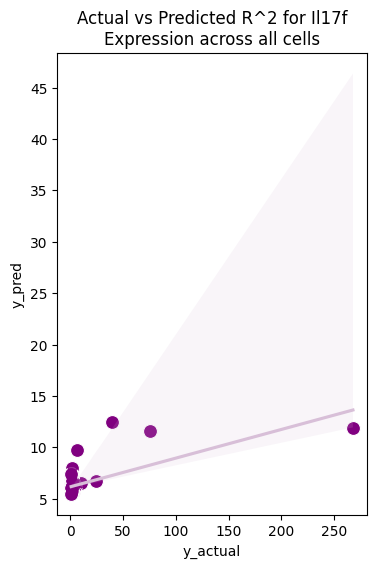

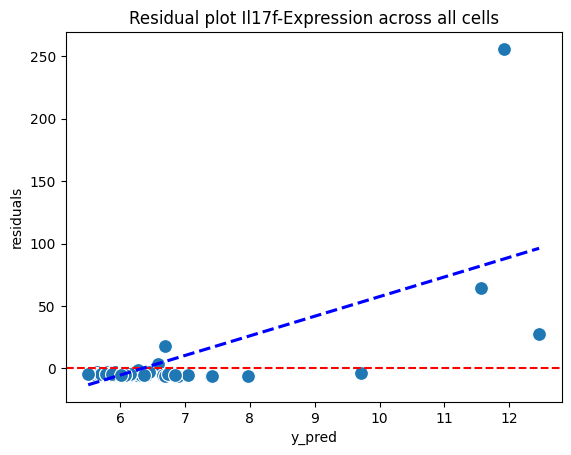

Il17f:CV=-3.792, peaks=30, best_alpha=10000


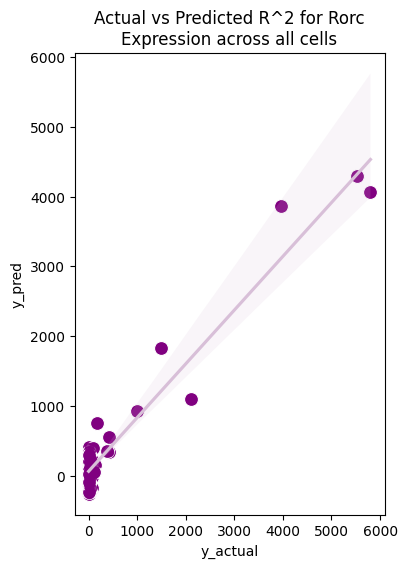

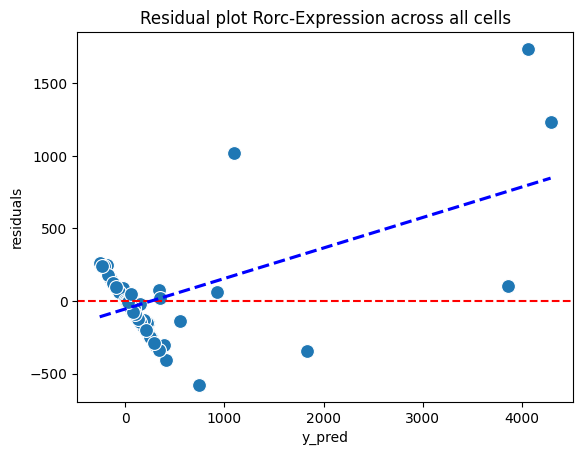

Rorc:CV=0.693, peaks=55, best_alpha=100


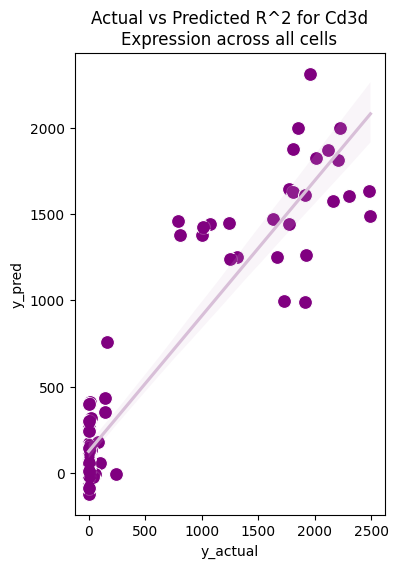

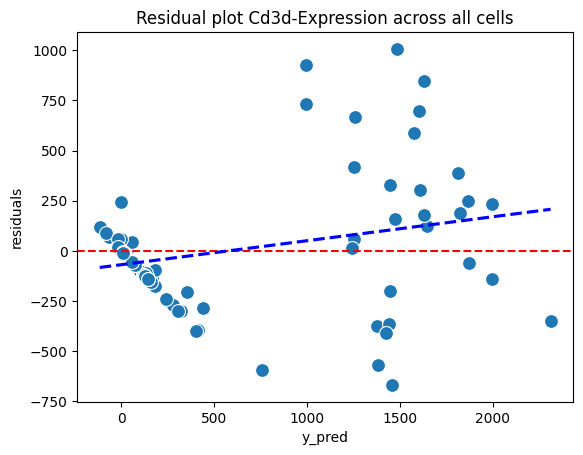

Cd3d:CV=0.750, peaks=72, best_alpha=100


In [32]:
for gen_name in ["Il17f", "Rorc","Cd3d"]: #more genes: "Sox13","Gzma", "Eomes", "Actb"
    _, cv, n,_, best_alpha,_,_,_ = r2_gen(gen_name, plot_residues=True, plot=True) #variabeln brauche ich hier für nicht
    print(f"{gen_name}:CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

<div class="alert alert-block alert-info">
A Ridge Regression model was built to predict gene expression through ATACseq peaks. <br>

Testing the model on **Cd3d** shows a stable fit with high explained variance due to its robust expression across cell types. **Rorc** demonstrates moderate performance. It relies on just a few peaks with higher variance, meaning the model's predictive power is heavily concentrated on those specific regions. <br> In contrast, applying the model to **Il17f** results in high uncertainty because fewer peaks are strongly associated with the gene and its variance is low, which heavily promotes overfitting. 

Thus the model can only be used to comparatively evaluate *Il17f* rather than to make precise predictions in further analysis.
</div>

### Function of the regression model (R^2): lineage-specific γδ T-cells

<h3> Preparing Dataset

In [ ]:
import pandas as pd
from pathlib import Path

RNA_seq_gd_path = Path('data') / 'RNA_seq_gd_anot.csv'
RNA_seq_gd = pd.read_csv(RNA_seq_gd_path)

ATAC_gd_path = Path('data') / 'ATAC_seq_gd.csv'
ATAC_seq_gd = pd.read_csv(ATAC_gd_path)

**Function R^2_gen**

1. Create a matrix: X = peaks, Y = gene expression
2. Run Ridge Regression to select best alpha
3. Cross Validation with best alpha
4. Plot predicted values vs actual values 
5. Create residual plot

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen_gd(gen_name_gd, plot=True, plot_residues=True):   # top_k weg
    # RNA
    RNA_seq_Tgd_gen = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen_name_gd]
    y = RNA_seq_Tgd_gen.drop("Unnamed: 0", axis=1, errors="ignore").T

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq_gd[ATAC_seq_gd["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name_gd}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks

    # gemeinsame Zellen angleichen
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]
    
    X_scaled = StandardScaler().fit_transform(X)

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=42))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_
    
    # CV mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    y_actual = np.ravel(y.values)
    y_pred = ridge.predict(X_scaled)

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted R^2 for {gen_name_gd}-Expression across Tgd cells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name_gd}-Expression across Tgd cells")
        plt.show()
    
    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids

#### Test Function: R²_gen_gd </h3> 
Genes tested:  
* *Rorc*: one of the genes with the highest Gini coefficient in γδ T-cells
* *Il17f*: gene active in IL17-producing cells  
* *Cd3d*: highly active T-cell marker with high expression variability across cell types<br> 
<br>Visualization with plots of predicted values and residual plots 

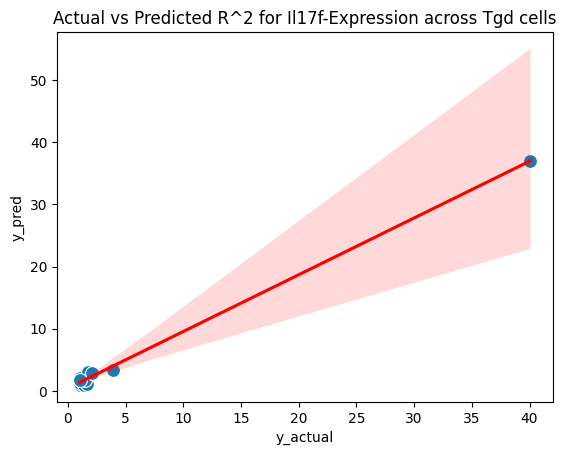

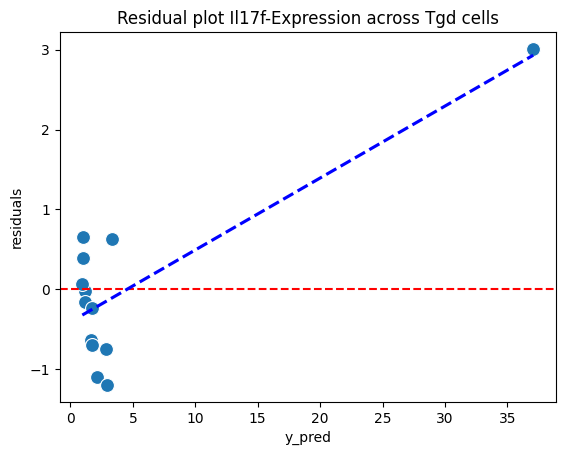

Il17f: CV=-25.579, peaks=30, best_alpha=10


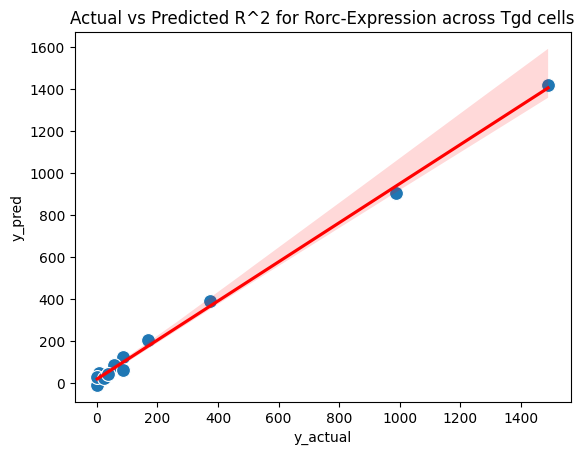

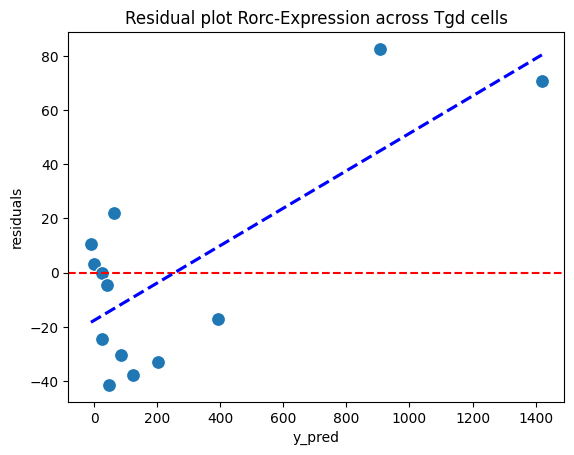

Rorc: CV=-3908.351, peaks=55, best_alpha=10


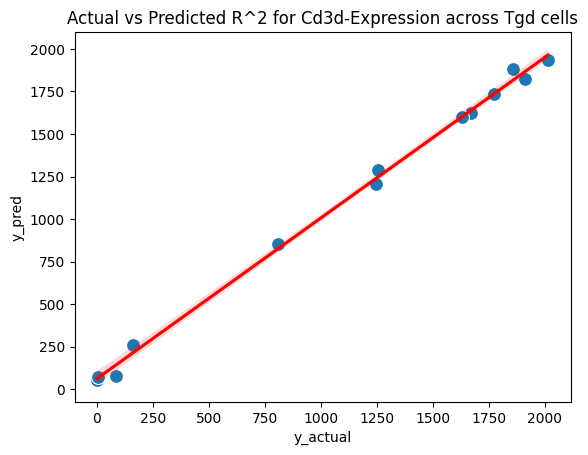

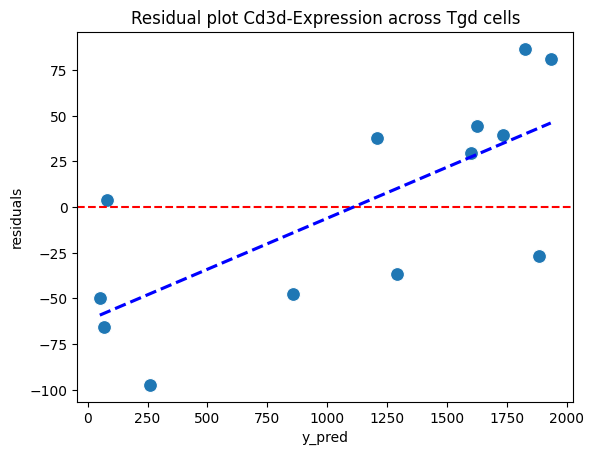

Cd3d: CV=-4.467, peaks=72, best_alpha=10


In [33]:
for gen_name_gd in ["Il17f", "Rorc", "Cd3d"]: #"Gzma", "Eomes", "Actb" 
    _, cv, n,_,best_alpha,_= r2_gen_gd(gen_name_gd)
    print(f"{gen_name_gd}: CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

<div class="alert alert-block alert-info">
A second Ridge model was trained specifically on γδ T-cell development. This model shows negative cross-validation scores, meaning it performs worse at predicting gene expression than simply guessing the mean of y for every cell type. This is because the model is trained on only 13 γδ T-cell types, making it highly prone to overfitting and it cannot generalize reliably within this limited cell lineage.
</div>



## How do regression coefficients change when the model is fit on your lineage alone versus all cell types?


<h3>Analysis of Ridge Regression Coefficients</h3>

$$\hat{Y}_i = b_0 + b_1 X_{i1} + b_2 X_{i2} + \dots + b_n X_{in}$$

In our model, each coefficient ($b_1, b_2, \dots, b_n$) represents the weight of a single peak. To evaluate how peak accessibility influences gene expression across the two models, we used the following approach:

1. For each gene, we will use the exact same set of peaks (common peak set) for both the all-cells and the Tγδ-specific models.
2. For every individual peak, we compare the sign (positive or negative) of its coefficient between the all-cells model and the Tgd model.
3. We calculate the total number and the proportion of peaks that change their sign between the two approaches to assess model stability and lineage-specific differences.

<h3> Comparison of coefficient values across tested genes

In [18]:
genes = "Il17f", "Arpp21",  "Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Actb", "Hprt", "Rplp0" ,"Cd3d"
results = []
coef_tables = {}  # speichert coef_table pro Gen

for gen in genes:
    r2_all,cv_all, n_all,reg_all,best_alpha_all,peaks_all,_,_ = r2_gen(gen, plot=False, plot_residues = False) #increasing rigid penalty to reduce overfitting
    r2_gd, _, n_gd, reg_gd, best_alpha_gd, peaks_gd = r2_gen_gd(gen, plot=False, plot_residues=False)
    
    #nur gemeinsame Peaks (verhindert Längen-Mismatch)
    coef_table = pd.DataFrame(
        {"all_cells": reg_all.coef_.ravel(),
         "Tgd":       reg_gd.coef_.ravel()},
        index=peaks_all                           # ImmGenATAC1219.peakID als Index
    )

    coef_table["gene"] = gen  # Gen-Spalte hinzufügen
    coef_tables[gen] = coef_table  # speichern

    sign_changes = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"])).sum()
    
    results.append({                            #append: erweitert Liste
        "gene": gen,
        "n_peaks": len(coef_table),
        "sign_changes": sign_changes,
        "percent_sign_changes": 100 * sign_changes / len(coef_table)
        })



coef_genes_compare = pd.DataFrame(results)
coef_genes_compare

,gene,n_peaks,sign_changes,percent_sign_changes
0,Il17f,30,11,36.666667
1,Arpp21,56,15,26.785714
2,Eomes,62,25,40.322581
3,Gzma,68,27,39.705882
4,Kcnk1,33,8,24.242424
5,Rorc,55,18,32.727273
6,Sox13,50,10,20.000000
7,Actb,85,28,32.941176
8,Hprt,36,7,19.444444
9,Rplp0,78,27,34.615385


#### Scatterplot
for selected genes: *Rorc*, *Il17f*
<br><br>

Visualize the coefficients using a scatter plot:

* **X-axis:** Regression Coefficient in the all-cells model
* **Y-axis:** Regression Coefficient in the Tgd model

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def scattplot_coef(gen): 
    coef_table = coef_tables[gen].copy()
    
    coef_table["sign_changes"] = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"]))

    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        data=coef_table,
        x="all_cells",
        y="Tgd",
        hue="sign_changes",
        palette={False: "steelblue", True: "tomato"},
        alpha=0.8
    )
    
    plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.plot(
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()], #diagonale die perfekt 45 Grad Winkel verläuft
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()],
        color="black", linestyle=":", linewidth=0.8,
        label="y = x"
    )

    plt.xlabel("Coefficient (all cells)")
    plt.ylabel("Coefficient (Tgd)")
    plt.title(f"{gen}: Regression coefficients\nall cells vs. Tgd")
    plt.legend(title="Sign change", loc="best")
    plt.tight_layout()
    plt.show()

*Actb*: Houskeeping gen

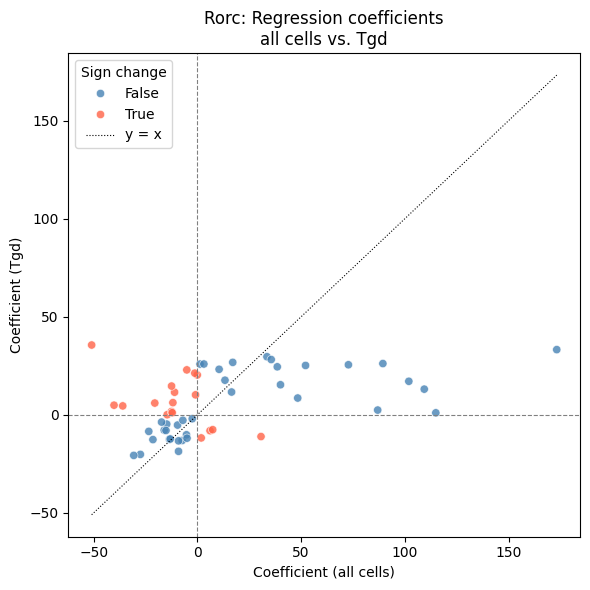

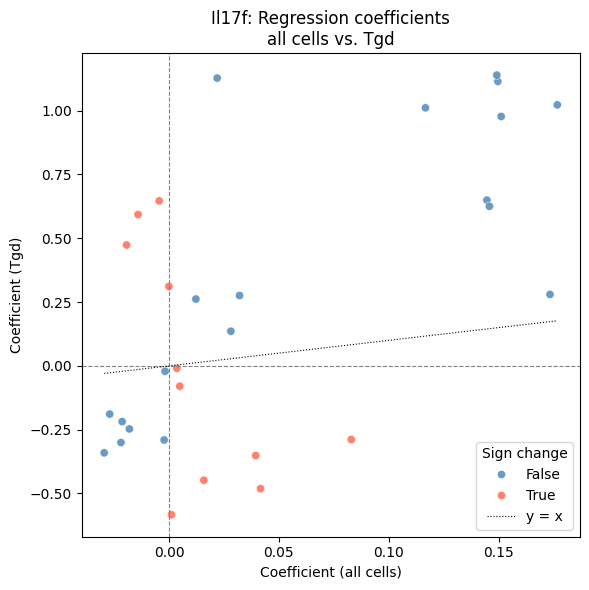

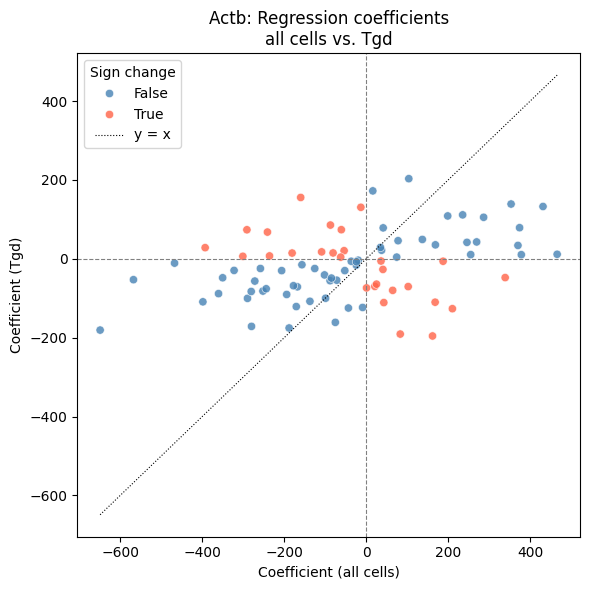

In [26]:
for gen in ["Rorc", "Il17f", "Actb"]: # "Gzma", "Eomes","Sox13","Cd3d",
    scattplot_coef(gen)

* *Actb*: points are symmetrical distributed around diagonal line
* *Rorc*: Similar to Actb, but peaks in the positive quadrant are weighted weaker in the Tγδ model
* *Il17f*: Model shows no clear pattern


## Which CREs drive expression of your lineage-specific genes?

Determine top CREs for specific genes by finding the highest absolute difference between the all-cells and Tγδ coefficients.

In [23]:
high_gini_Tgd = ["Il17f", "Cd3d", "Rorc"]# "Gzma", "Kcnk1", "Rorc", "Sox13", "Il17f", "Cd3d"

for gen in high_gini_Tgd:
    # filtern absolut
    filtered = coef_tables[gen][abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])].copy()
    
    #spalte für den absoluten Abstand
    filtered["abs_distance"] = filtered["Tgd"].abs()
    
    #Nach absolutem Abstand sortieren und Spalte dann löschen
    top_drive = filtered.sort_values("abs_distance", ascending=False).drop(columns=["abs_distance"]) 

    print(f"\n{gen} – Top Tγδ-driving CREs:")
    print(top_drive.head(10))


Il17f – Top Tγδ-driving CREs:
                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f
ImmGenATAC1219.peak_2081   0.151196  0.977415  Il17f
ImmGenATAC1219.peak_2083   0.144711  0.649584  Il17f
ImmGenATAC1219.peak_2109  -0.004486  0.646648  Il17f
ImmGenATAC1219.peak_2085   0.145833  0.625246  Il17f
ImmGenATAC1219.peak_2116  -0.014109  0.593164  Il17f

Cd3d – Top Tγδ-driving CREs:
                            all_cells        Tgd  gene
ImmGenATAC1219.peak_482211  20.444442  47.107933  Cd3d
ImmGenATAC1219.peak_482197  26.288307  45.671452  Cd3d
ImmGenATAC1219.peak_482235 -14.626588 -39.689922  Cd3d
ImmGenATAC1219.peak_482172 -24.734433 -38.852603  Cd3d
ImmGenATAC1219.peak_482176   7.168351 -38.841240  Cd3d
ImmGenATAC1219.peak_482202

**Visualization** 
The top 5 Tγδ peaks per gene are used to analyze the association between the chromatin accessibility of each peak and the gene expression across the γδ lineage. 

                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f
                            all_cells        Tgd  gene
ImmGenATAC1219.peak_312422  17.029479  26.728689  Rorc
ImmGenATAC1219.peak_312426   3.125627  25.887710  Rorc
ImmGenATAC1219.peak_312420   1.265211  25.848735  Rorc
ImmGenATAC1219.peak_312447  10.458059  23.193540  Rorc
ImmGenATAC1219.peak_312421  -5.105702  22.888483  Rorc


/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_11845/3326886006.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


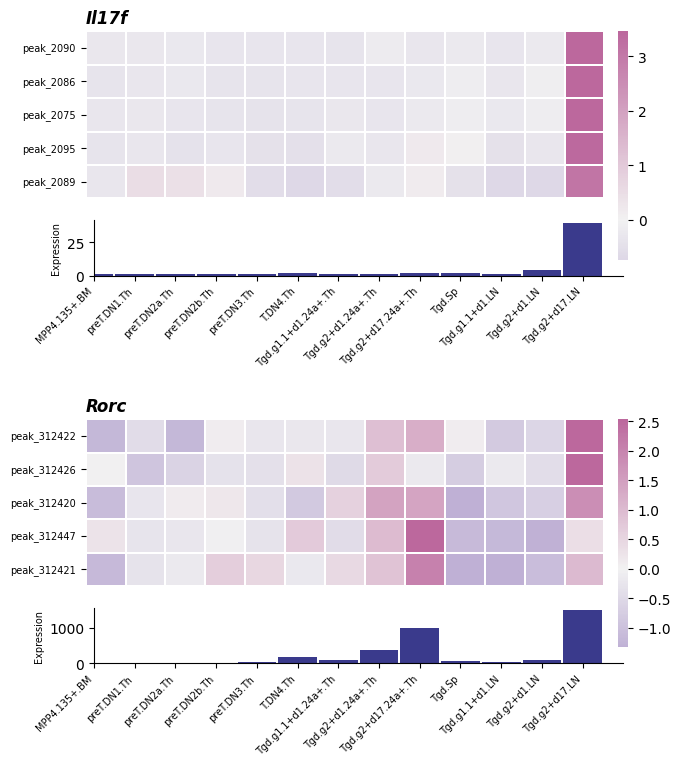

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Tgd_cells = [
        "MPP4.135+.BM",
        "preT.DN1.Th",
        "preT.DN2a.Th",
        "preT.DN2b.Th",
        "preT.DN3.Th",
        "T.DN4.Th",
        "Tgd.g1.1+d1.24a+.Th",
        "Tgd.g2+d1.24a+.Th",
        "Tgd.g2+d17.24a+.Th",
        "Tgd.Sp",
        "Tgd.g1.1+d1.LN",
        "Tgd.g2+d1.LN",
        "Tgd.g2+d17.LN"
    ]

cmap = sns.diverging_palette(
        280,
        330,
        s=45,
        l=55,
        center="light",
        as_cmap=True
    )

genes = ["Il17f", "Rorc"]#, "Il17f", "Cd3d", "Rorc"

fig = plt.figure(figsize=(7, 4 * len(genes)))
outer = fig.add_gridspec(
        len(genes), 2,
        width_ratios=[50, 1],
        wspace=0.05,
        hspace=0.7
    )

for i, gen in enumerate(genes):
        # Inneres gridspec: Heatmap oben (3 Teile), Barplot unten (1 Teil)
        inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

        ax_heat = fig.add_subplot(inner[0])
        ax_bar = fig.add_subplot(inner[1], sharex=ax_heat)
        cax = fig.add_subplot(outer[i, 1])

        filtered_coef = coef_tables[gen][abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])].copy()
        top5 = filtered_coef.sort_values("Tgd", ascending=False).head(5)
        print(top5)

        rows = []
        for peak_id in top5.index:
            row = ATAC_seq_gd[ATAC_seq_gd["ImmGenATAC1219.peakID"] == peak_id]
            if not row.empty:
                vals = row[Tgd_cells].iloc[0]
                sauberer_name = peak_id.replace("ImmGenATAC1219.", "") #ImmgenATAC1219 in y-Achse Beschriftung rausgenommen
                vals.name = sauberer_name
                rows.append(vals)

        heat_df = pd.DataFrame(rows)
        heat_df_z = StandardScaler().fit_transform(heat_df.T) # skaliert über Tgd-Zelltypen je Peak (dafür transformieren) --> damit alle peaks auf derselben skala liegen (z=2: Standartabweichung 2 besonders offen für den peak)
        heat_df_z = pd.DataFrame(heat_df_z.T, index=heat_df.index, columns=heat_df.columns)

        sns.heatmap(
            heat_df_z,
            ax=ax_heat,
            cmap=cmap,
            center=0,
            robust=True,
            linewidths=0.3,
            xticklabels=False,
            yticklabels=True,
            cbar=True,
            cbar_ax=cax
        )

        ax_heat.set_title(gen, fontstyle="italic", fontweight="bold", loc="left")

        # Heatmap-Zellnamen kleiner
        ax_heat.tick_params(axis='x', labelbottom=False, bottom=False)   # z.B. 7 oder 8
        ax_heat.tick_params(axis='y', labelsize=7)   # z.B. 7 oder 8

        rna_row = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen]
        # Barplot RNA: RNA‑Expression des Gens in den Tγδ‑Zelltypen
        if not rna_row.empty:
            rna_vals = rna_row[Tgd_cells].iloc[0]

            ax_bar.bar(
                np.arange(len(Tgd_cells)),
                rna_vals.values,
                width=0.95,
                color="#3a3a8c"
            )
            ax_bar.set_xticks(np.arange(len(Tgd_cells)))
            ax_bar.set_xticklabels(Tgd_cells, rotation=45, ha="right", fontsize=7)
            ax_bar.set_ylabel("Expression", fontsize=7)
            ax_bar.spines[["top", "right"]].set_visible(False)

        ax_heat.set_xlim(0, len(Tgd_cells))
        ax_bar.set_xlim(0, len(Tgd_cells))

        heat_pos = ax_heat.get_position()
        bar_pos = ax_bar.get_position()

        # Barplot nach rechts, nach unten und etwas länger
        ax_bar.set_position([
            heat_pos.x0 + 0.012,      # nach rechts
            bar_pos.y0 - 0.02,        # nach unten
            heat_pos.width + 0.015,   # etwas länger/breiter
            bar_pos.height
        ])
#plt.savefig(f"plots_for_poster/top_peaks_ATAC_RNA_{genes}", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

*Il17f*
* Accessibility and gene expression of the top peaks chosen with the regression model are almost entirely restricted to Tgd.g2+d17.LN.

*Rorc*
* Broad regulatory pattern, not completly restricted to a single early subset
* Chromatin accessibility and gene expression rise after the precursor T-cell stages
* High in chromatin accessibilty and expression in the mature Tgd.g2+d17.24a+.Th and Tgd.g2+d17.LN populations

<div class="alert alert-block alert-info">
Considering the limitations of the models, specifically the lineage-specific one, a correlation analysis (see 2.3) is more trustworthy.
</div>

# Peter

In [ ]:
plt.savefig('plots for poster/Regression', dpi=300)

NameError: name 'plt' is not defined

#### Ammending the Plot - Peter

##### Einfach zu klappen und laufen lassen

In [ ]:
#Datasets
import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline 
from pathlib import Path


#RNA Data
RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)
RNAseq_reg = RNA_seq.copy()

##ATAC Data general
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)

##ATAC Data without unreliable Data
threshold = -np.log10(0.05)
ATAC_data_removed = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_data_removed.__len__() 

annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATACseq_reg = ATAC_data_removed[ATAC_data_removed["TSS"].isnull()]


print(RNAseq_reg.head())


      Unnamed: 0  LTHSC.34-.BM  LTHSC.34+.BM  STHSC.150-.BM  MPP4.135+.BM  \
0  0610005C13Rik      1.096732      1.096732       1.021750      1.021812   
1  0610007P14Rik    206.053987    246.105317     192.424636    204.298358   
2  0610009B22Rik     78.272059     78.837030      68.844751     76.418169   
3  0610009L18Rik      8.577159     16.791386      15.511549     16.947354   
4  0610009O20Rik    168.645852    157.926022     155.941641    186.261464   

   proB.CLP.BM  proB.FrA.BM  proB.FrBC.BM    B.FrE.BM      B1b.PC  ...  \
0     1.205236     1.326780      1.392996    1.821243    1.025543  ...   
1   189.759175   210.195155    180.219440  137.802543  139.436719  ...   
2   106.085619    77.502817     68.213092   57.224426   56.787489  ...   
3    10.583704     8.664784      2.878172    8.952120   11.873984  ...   
4   162.584556   152.088002    163.072291  133.116083   88.052982  ...   

        MF.PC   MF.Fem.PC    DC.4+.Sp    DC.8+.Sp   DC.pDC.Sp     FRC.SLN  \
0    1.025785  

In [ ]:
#build_gene_peak_dict(ATAC_seq)

def build_gene_peak_dict(ATAC_seq):

    gene_to_peaks = {}

    ATAC_filtered = ATAC_seq[ATAC_seq["genes.within.100Kb"].notna()]

    for index, row in ATAC_filtered.iterrows():

        peak_ID = row["ImmGenATAC1219.peakID"]

        for gene in str(row["genes.within.100Kb"]).split(","):
            
            gene = gene.strip()

            if gene not in gene_to_peaks:
                gene_to_peaks[gene] = []
            
            gene_to_peaks[gene].append(peak_ID)

    return gene_to_peaks

gene_peak_dictionary = build_gene_peak_dict(ATAC_data_removed)

In [ ]:
#f: r2_gen_TSS

ATACseq_reg_TSS = ATAC_data_removed.copy()

def r2_gen_TSS(gen_name, plot=True, plot_residues = True):
    #Y_RNA
    RNA_seq_Gene = RNAseq_reg[RNAseq_reg["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    peak_ids = gene_peak_dictionary.get(gen_name, [])
    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["ImmGenATAC1219.peakID"].isin(peak_ids)]

    ##ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    ##peak_ids = ATACseq_reg_TSS["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    #für Vergleich von Y
    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    ci=None, line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted y for {gen_name}-Expression across all cells inkl. TSS")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells inkl. TSS")
        plt.show()
        
    return  r2, cv, ridge


for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, ridge= r2_gen_TSS(gen_name, plot=False, plot_residues=False)
    print(f"{gen_name}_all: R²={r2:.3f}, CV={cv:.3f}")

Il17f_all: R²=0.054, CV=-4.165
Rorc_all: R²=0.905, CV=0.659
Sox13_all: R²=0.450, CV=-203.209
Gzma_all: R²=0.986, CV=0.899
Eomes_all: R²=0.986, CV=0.928
Actb_all: R²=0.633, CV=0.163


In [ ]:
#f: coef_gen

def coef_gen(gen_name):
    r2, cv, ridge = r2_gen_TSS(gen_name, plot=False, plot_residues=False) #Falls Error: Anpassen welche Ridge Funktion benutzt wird!

    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATAC_seq_Gene["ImmGenATAC1219.peakID"].values

    coef_df = pd.DataFrame({"peak_id": peak_ids, "coefficient": ridge.coef_})

    #eine Spalte soll direkt Vorzeicehn interpretieren
    coef_df["sign"] = coef_df["coefficient"].apply(lambda x: "+" if x > 0 else "-")

    # Effektstärke
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs().round(1)

    #inaktiv# Sortieren aktiv und repressvi
    #coef_df["sign_order"] = coef_df["sign"].map({"repressing": 0,"activating": 1})

    # zuerst repressing/activating, dann nach Stärke
    coef_df = coef_df.sort_values(by=["abs_coefficient"], ascending=[False])

    #inaktiv# Hilfsspalte wieder entfernen
    ##coef_df = coef_df.drop(columns="sign_order")

    return coef_df, r2, cv, peak_ids

coef_Gzma, r2, cv, peak_ids = coef_gen("Gzma")
coef_Gzma["abs_coefficient"].describe()
coef_Gzma

,peak_id,coefficient,sign,abs_coefficient
26,ImmGenATAC1219.peak_142098,715.915569,+,715.9
21,ImmGenATAC1219.peak_142093,486.993120,+,487.0
53,ImmGenATAC1219.peak_142129,412.479079,+,412.5
40,ImmGenATAC1219.peak_142114,409.974730,+,410.0
22,ImmGenATAC1219.peak_142094,-393.385473,-,393.4
...,...,...,...,...
46,ImmGenATAC1219.peak_142120,-8.826416,-,8.8
67,ImmGenATAC1219.peak_142147,8.322973,+,8.3
55,ImmGenATAC1219.peak_142133,-7.726329,-,7.7
64,ImmGenATAC1219.peak_142144,-2.435170,-,2.4


In [ ]:
#creating plot_df

genes = ["Rorc", "Il17f", "Eomes"]
strong_threshold = 10

plot_rows = []

for gene in genes:
    coef_df, r2, cv, peak_ids = coef_gen(gene)

    coef_df["category"] = "weak activator"

    coef_df.loc[
        coef_df["coefficient"] < 0,
        "category"
    ] = "repressor"

    coef_df.loc[
        coef_df["coefficient"] >= strong_threshold,
        "category"
    ] = "strong activator"

    temp = coef_df[["peak_id", "coefficient", "category"]].copy()
    temp["gene"] = gene

    plot_rows.append(temp)

plot_df = pd.concat(plot_rows, ignore_index=True)

display(
    plot_df.groupby(["gene", "category"]).size()
)

gene   category        
Eomes  repressor           28
       strong activator    16
       weak activator      18
Il17f  repressor           11
       weak activator      19
Rorc   repressor           32
       strong activator    18
       weak activator       5
dtype: int64

##### Hier Plot verändern

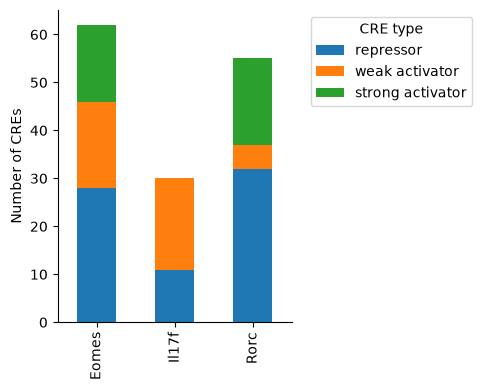

In [ ]:
#creating plot

plot_counts = (
    plot_df
    .groupby(["gene", "category"])
    .size()
    .unstack(fill_value=0)
)

plot_counts = plot_counts[
    ["repressor",
     "weak activator",
     "strong activator"]
]

ax = plot_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(5,4)
)

ax.set_ylabel("Number of CREs")
ax.set_xlabel("")
ax.legend(
    title="CRE type",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# combining plots